# CE314 Natural Language Engineering  
## Assignment 2 – Emotion Classification (2025)

**Student Name:** Sneha Tandon  
**Module:** CE314 Natural Language Engineering  
**Assignment Weight:** 20%  
**Dataset:** Emotion Classification (Twitter)  
**Notebook Environment:** Google Colab

This notebook presents the design, implementation, and evaluation of a supervised
text classification model for emotion detection in English Twitter messages.


In [1]:
!python --version
!pip --version

Python 3.12.12
pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)


In [2]:
!pip install -q kagglehub

In [3]:
!pip freeze > requirements.txt

## Note: Not all the packages are used.


In [4]:
!pip list

Package                                  Version
---------------------------------------- --------------------
absl-py                                  1.4.0
accelerate                               1.12.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.2
aiosignal                                1.4.0
aiosqlite                                0.22.0
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.17.2
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                        

# Imports


In [5]:
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem import WordNetLemmatizer

import kagglehub

Random seeds are fixed to ensure reproducibility, and epoch training time is recorded.

In [6]:
import random
import time

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def epochTime(start, end):
    elapsed = end - start
    return int(elapsed // 60), int(elapsed % 60)


In [7]:
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)


True

In [8]:
path = kagglehub.dataset_download("praveengovi/emotions-dataset-for-nlp")
csvPath = os.path.join(path, "train.txt")

df = pd.read_csv(csvPath, sep=";", names=["text", "label"])
df.head()

Using Colab cache for faster access to the 'emotions-dataset-for-nlp' dataset.


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


Labels are converted to numeric class IDs using a label encoder, with the number of classes inferred from the encoded labels.

In [9]:
encoderLabel = LabelEncoder()
df["label_id"] = encoderLabel.fit_transform(df["label"])

numberOfClasses = len(encoderLabel.classes_)
encoderLabel.classes_

array(['anger', 'fear', 'joy', 'love', 'sadness', 'surprise'],
      dtype=object)

Text is lowercased, cleaned of URLs, mentions, punctuation, and non-alphabetic characters, then tokenised with optional stopword removal and lemmatisation.

In [10]:
def preprocessText(text, lemmatize=True, removeStopwords=True):
    if not isinstance(text, str):
        text = str(text)

    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+|#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)

    if removeStopwords:
        stopWords = set(nltk_stopwords.words("english"))
        tokens = [w for w in tokens if w not in stopWords and len(w) > 1]
    else:
        tokens = [w for w in tokens if len(w) > 1]

    if lemmatize:
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return " ".join(tokens)


After preprocessing, we analyse label distribution, token length distribution, and the most frequent tokens to understand class balance and text characteristics.

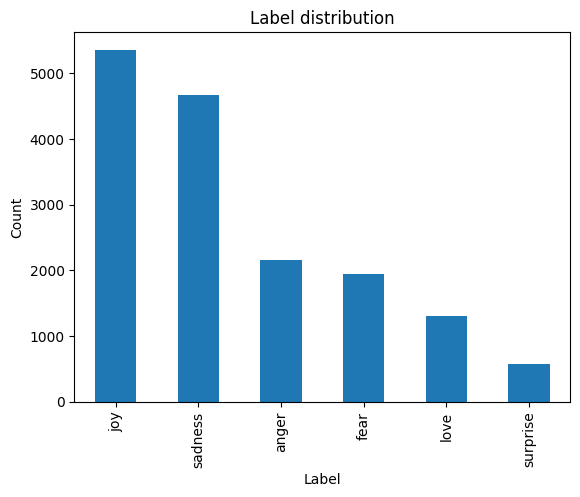

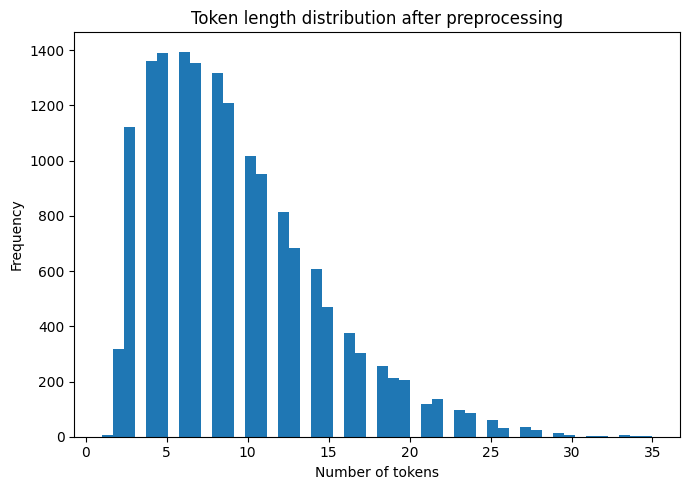

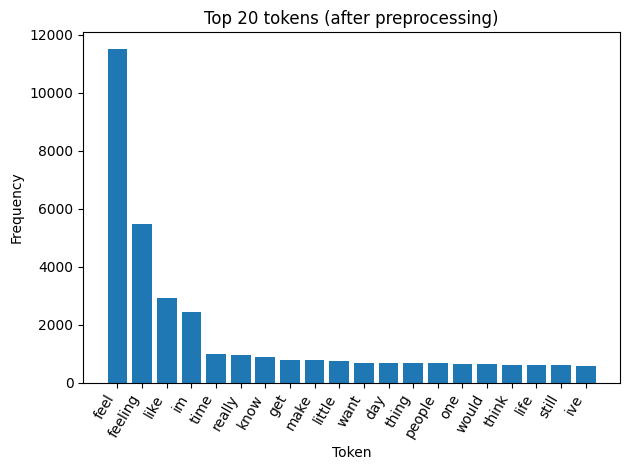

In [11]:
nltk.download("punkt_tab", quiet=True)

df["cleanText"] = df["text"].apply(preprocessText)

# Label distribution
labelCounts = df["label"].value_counts()
plt.figure()
labelCounts.plot(kind="bar")
plt.title("Label distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# Text length distribution (cleanText)
df["cleanLength"] = df["cleanText"].apply(lambda x: len(x.split()))
plt.figure(figsize=(7, 5))
plt.hist(df["cleanLength"], bins=50)
plt.title("Token length distribution after preprocessing")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Top tokens
totalTokens = " ".join(df["cleanText"].tolist()).split()
top = Counter(totalTokens).most_common(20)
topWords, topFrequency = zip(*top)

plt.figure()
plt.bar(range(len(topWords)), topFrequency)
plt.xticks(range(len(topWords)), topWords, rotation=60, ha="right")
plt.title("Top 20 tokens (after preprocessing)")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [12]:
df["cleanText"] = df["text"].apply(preprocessText)
df.head()

,text,label,label_id,cleanText,cleanLength
0,i didnt feel humiliated,sadness,4,didnt feel humiliated,3
1,i can go from feeling so hopeless to so damned...,sadness,4,go feeling hopeless damned hopeful around some...,9
2,im grabbing a minute to post i feel greedy wrong,anger,0,im grabbing minute post feel greedy wrong,7
3,i am ever feeling nostalgic about the fireplac...,love,3,ever feeling nostalgic fireplace know still pr...,7
4,i am feeling grouchy,anger,0,feeling grouchy,2


In [13]:
train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df["label_id"]
)

len(train_df), len(val_df), len(test_df)


(12800, 1600, 1600)

We construct a vocabulary from the training data with minimum frequency filtering, including special padding and unknown tokens, and encode sentences as fixed-length index sequences.

In [14]:
class Vocabulary:
    PAD = 0
    UNK = 1

    def __init__(self, minimumFrequency=2):
        self.minimumFrequency = minimumFrequency
        self.wordToIndex = {"<PAD>": self.PAD, "<UNK>": self.UNK}
        self.indexToWord = {self.PAD: "<PAD>", self.UNK: "<UNK>"}
        self.wordFrequency = {}

    def build(self, sentences):
        counter = Counter()
        for s in sentences:
            counter.update(s.split())

        self.wordFrequency = {
            w: f for w, f in counter.items() if f >= self.minimumFrequency
        }

        index = len(self.wordToIndex)
        for w in sorted(self.wordFrequency.keys()):
            self.wordToIndex[w] = index
            self.indexToWord[index] = w
            index += 1

    def encode(self, sentence, maxLength=None):
        words = sentence.split()
        if maxLength:
            words = words[:maxLength]

        ids = [self.wordToIndex.get(w, self.UNK) for w in words]

        if maxLength:
            ids += [self.PAD] * (maxLength - len(ids))

        return ids


In [15]:
vocabulary= Vocabulary(minimumFrequency=2)
vocabulary.build(train_df["cleanText"].tolist())

vocabularySize = len(vocabulary.wordToIndex)
vocabularySize


5780

A custom dataset maps preprocessed texts to padded token IDs and labels, while a collate function batches sequences and preserves their true lengths.

In [16]:
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, vocabulary, maxLength=50):
        self.texts = list(texts)
        self.labels = list(labels)
        self.vocabulary = vocabulary
        self.maxLength = maxLength

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = self.texts[index]
        label = int(self.labels[index])

        ids = self.vocabulary.encode(text, self.maxLength)
        length = sum(1 for i in ids if i != Vocabulary.PAD)

        return {
            "text": torch.tensor(ids, dtype=torch.long),
            "label": torch.tensor(label, dtype=torch.long),
            "length": torch.tensor(length, dtype=torch.long),
        }


def collate_fn(batch):
    texts = [b["text"] for b in batch]
    labels = torch.stack([b["label"] for b in batch])
    lengths = torch.stack([b["length"] for b in batch])

    texts = pad_sequence(texts, batch_first=True, padding_value=Vocabulary.PAD)
    return {"text": texts, "label": labels, "length": lengths}

In [17]:
trainDataset = EmotionDataset(train_df["cleanText"], train_df["label_id"], vocabulary)
validatingDataset = EmotionDataset(val_df["cleanText"], val_df["label_id"], vocabulary)
testDataset = EmotionDataset(test_df["cleanText"], test_df["label_id"], vocabulary)

trainLoader = DataLoader(trainDataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
validationLoader = DataLoader(validatingDataset, batch_size=64, shuffle=False, collate_fn=collate_fn)
testLoader = DataLoader(testDataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

We implement a multi-layer bidirectional LSTM with learned embeddings and dropout, using the final hidden states for sentence-level emotion classification.

In [18]:
class EmotionLSTM(nn.Module):
    def __init__(self, vocabularySize, embedding_dim, hidden_dim, output_dim, n_layers=2, dropout=0.5, bidirectional=True):
        super().__init__()
        self.embedding = nn.Embedding(vocabularySize, embedding_dim, padding_idx=Vocabulary.PAD)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim,
            num_layers=n_layers,
            bidirectional=bidirectional,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)

        lstm_out_dim = hidden_dim * (2 if bidirectional else 1)
        self.fc = nn.Linear(lstm_out_dim, output_dim)

    def forward(self, text, lengths):
        embedded = self.dropout(self.embedding(text))
        packed = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)

        if self.lstm.bidirectional:
            h = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            h = hidden[-1]

        return self.fc(self.dropout(h))

Training is performed in mini-batches with backpropagation and gradient clipping (max norm 1.0); evaluation returns validation loss/accuracy and stores predictions and logits for later analysis, with early stopping via patience.

In [19]:
def train1Epoch(model, loader, optimizer, criterion, device):
    model.train()
    totalLoss = 0.0

    for batch in loader:
        optimizer.zero_grad()

        text = batch["text"].to(device)
        labels = batch["label"].to(device)
        lengths = batch["length"].to(device)

        logits = model(text, lengths)
        loss = criterion(logits, labels)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        totalLoss += loss.item()

    return totalLoss / max(1, len(loader))


@torch.no_grad()
def evaluationMetrics(model, loader, criterion, device):
    model.eval()
    totalLoss = 0.0
    preds, trues = [], []
    all_logits = []

    for batch in loader:
        text = batch["text"].to(device)
        labels = batch["label"].to(device)
        lengths = batch["length"].to(device)

        logits = model(text, lengths)
        loss = criterion(logits, labels)
        totalLoss += loss.item()

        pred = logits.argmax(dim=1)
        preds.extend(pred.cpu().numpy())
        trues.extend(labels.cpu().numpy())
        all_logits.extend(logits.cpu().numpy())

    acc = accuracy_score(trues, preds)
    return totalLoss / max(1, len(loader)), acc, np.array(trues), np.array(preds), np.array(all_logits)


def fit_model(model, trainLoader, validationLoader, optimizer, criterion, device, max_epochs=50, patience=5):
    history = {"trainLoss": [], "validationLoss": [], "validationAccuracy": []}
    bestAccuracy = -1.0
    bestState = None
    patienceLeft = patience

    for epoch in range(1, max_epochs + 1):
        start = time.time()

        trainLoss = train1Epoch(model, trainLoader, optimizer, criterion, device)
        validationLoss, validationAccuracy, _, _, _ = evaluationMetrics(model, validationLoader, criterion, device)

        history["trainLoss"].append(trainLoss)
        history["validationLoss"].append(validationLoss)
        history["validationAccuracy"].append(validationAccuracy)

        end = time.time()
        m, s = epochTime(start, end)
        print(f"Epoch {epoch:02d} | {m}m {s}s | trainLoss {trainLoss:.4f} | validationLoss {validationLoss:.4f} | validationAccuracy {validationAccuracy:.4f}")

        if validationAccuracy > bestAccuracy:
            bestAccuracy = validationAccuracy
            bestState = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patienceLeft = patience
        else:
            patienceLeft -= 1
            if patienceLeft <= 0:
                print("Early stopping triggered.")
                break

    if bestState is not None:
        model.load_state_dict(bestState)

    return history, bestAccuracy

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def plotConfusionMatrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(range(len(class_names)), class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()

    plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

Each experiment applies the chosen preprocessing settings, trains the BiLSTM on the train split (vocab from train only), and evaluates on the held-out test set, returning accuracy, losses, and logits.

In [21]:
def runExperiment(config, seed=42, max_epochs=8):
    set_seed(seed)

    # Rebuild cleanText for this ablation
    trainLocal = train_df.copy()
    validationLocal = val_df.copy()
    testLocal = test_df.copy()

    trainLocal["cleanText"] = trainLocal["text"].apply(lambda t: preprocessText(t, lemmatize=config["lemmatize"], removeStopwords=config["stopwords"]))
    validationLocal["cleanText"] = validationLocal["text"].apply(lambda t: preprocessText(t, lemmatize=config["lemmatize"], removeStopwords=config["stopwords"]))
    testLocal["cleanText"] = testLocal["text"].apply(lambda t: preprocessText(t, lemmatize=config["lemmatize"], removeStopwords=config["stopwords"]))

    # Build vocabularyONLY on train split (correct practice)
    vocabulary = Vocabulary(minimumFrequency=config["min_freq"])
    vocabulary.build(trainLocal["cleanText"].tolist())
    vocabularySize = len(vocabulary.wordToIndex)

    # Datasets/loaders
    trainDataset = EmotionDataset(trainLocal["cleanText"], trainLocal["label_id"], vocabulary, maxLength=config["max_len"])
    validatingDataset = EmotionDataset(validationLocal["cleanText"], validationLocal["label_id"], vocabulary, maxLength=config["max_len"])
    testDataset = EmotionDataset(testLocal["cleanText"], testLocal["label_id"], vocabulary, maxLength=config["max_len"])

    trainLoader = DataLoader(trainDataset, batch_size=config["batch_size"], shuffle=True, collate_fn=collate_fn)
    validationLoader = DataLoader(validatingDataset, batch_size=config["batch_size"], shuffle=False, collate_fn=collate_fn)
    testLoader = DataLoader(testDataset, batch_size=config["batch_size"], shuffle=False, collate_fn=collate_fn)

    # Model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = EmotionLSTM(vocabularySize=vocabularySize, embedding_dim=config["emb_dim"], hidden_dim=config["hidden_dim"], output_dim=numberOfClasses, n_layers=config["layers"], dropout=config["dropout"], bidirectional=config["bidirectional"],).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    history, best_val = fit_model(
        model, trainLoader, validationLoader, optimizer, criterion, device,
        max_epochs=max_epochs, patience=config["patience"]
    )

    # Test
    testLoss, testAccuracy, y_true, y_pred, test_logits = evaluationMetrics(model, testLoader, criterion, device)

    return {"history": history, "bestValidationAccuracy": best_val, "testAccuracy": float(testAccuracy), "testLoss": float(testLoss), "y_true": y_true, "y_pred": y_pred, "test_logits": test_logits}

Epoch 01 | 0m 3s | trainLoss 1.5514 | validationLoss 1.3737 | validationAccuracy 0.4606
Epoch 02 | 0m 2s | trainLoss 1.3338 | validationLoss 0.9743 | validationAccuracy 0.6525
Epoch 03 | 0m 2s | trainLoss 1.0552 | validationLoss 0.6462 | validationAccuracy 0.7669
Epoch 04 | 0m 2s | trainLoss 0.8330 | validationLoss 0.4470 | validationAccuracy 0.8450
Epoch 05 | 0m 2s | trainLoss 0.6791 | validationLoss 0.3673 | validationAccuracy 0.8694
Epoch 06 | 0m 2s | trainLoss 0.5799 | validationLoss 0.3407 | validationAccuracy 0.8744
Epoch 07 | 0m 2s | trainLoss 0.5031 | validationLoss 0.2819 | validationAccuracy 0.8962
Epoch 08 | 0m 2s | trainLoss 0.4376 | validationLoss 0.2547 | validationAccuracy 0.9012
Epoch 09 | 0m 2s | trainLoss 0.4005 | validationLoss 0.2195 | validationAccuracy 0.9106
Epoch 10 | 0m 2s | trainLoss 0.3507 | validationLoss 0.2238 | validationAccuracy 0.9087


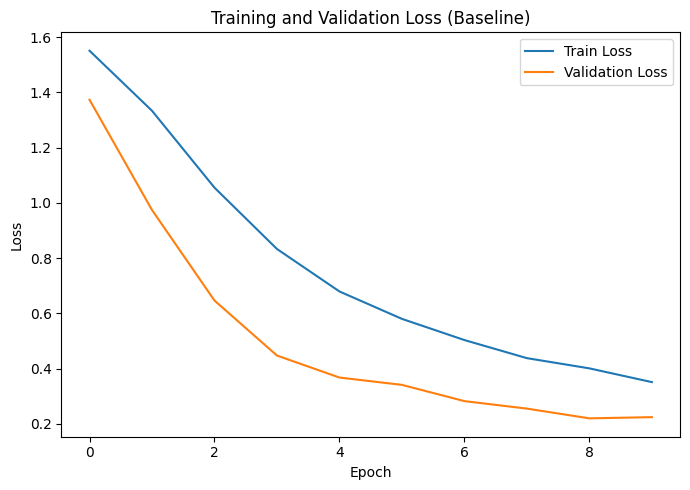

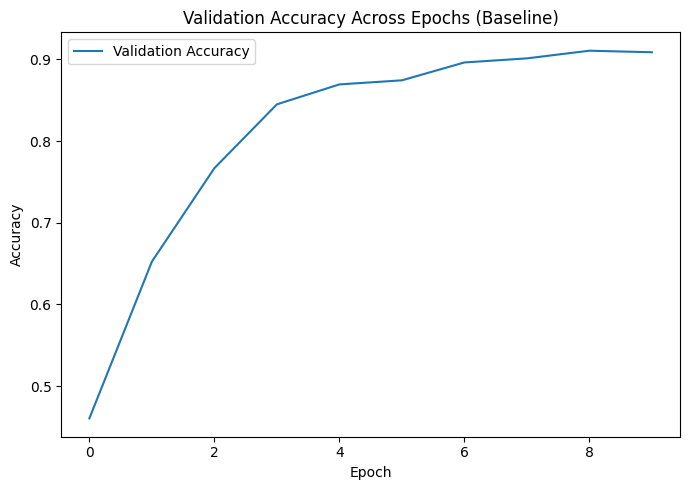

Best Val Acc: 0.910625
Test Acc: 0.90375
              precision    recall  f1-score   support

       anger       0.93      0.86      0.89       216
        fear       0.87      0.87      0.87       193
         joy       0.92      0.93      0.92       536
        love       0.76      0.82      0.79       130
     sadness       0.95      0.95      0.95       467
    surprise       0.76      0.83      0.79        58

    accuracy                           0.90      1600
   macro avg       0.86      0.87      0.87      1600
weighted avg       0.91      0.90      0.90      1600



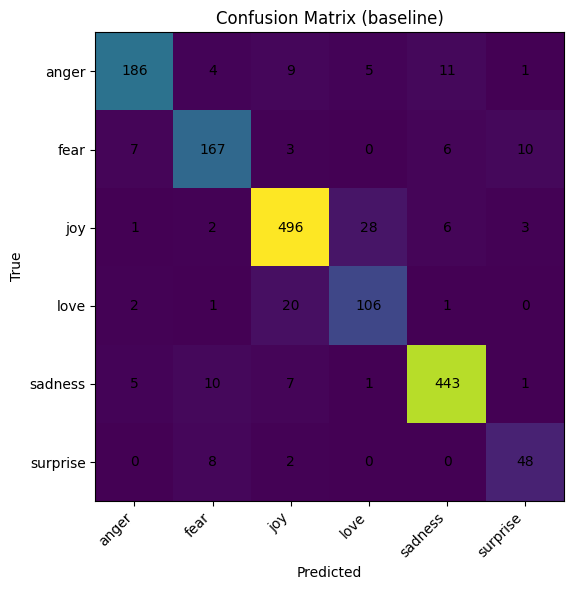

In [22]:
baseline = {"name": "baseline", "lemmatize": True, "stopwords": True, "min_freq": 2, "max_len": 50, "batch_size": 64, "emb_dim": 100, "hidden_dim": 128, "layers": 2, "dropout": 0.5, "bidirectional": True, "lr": 1e-3, "patience": 2}

out = runExperiment(baseline, seed=42, max_epochs=10)

# Learning curves
plt.figure(figsize=(7, 5))
plt.plot(out["history"]["trainLoss"], label="Train Loss")
plt.plot(out["history"]["validationLoss"], label="Validation Loss")
plt.title("Training and Validation Loss (Baseline)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("baseline_loss_curves.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(7, 5))
plt.plot(out["history"]["validationAccuracy"], label="Validation Accuracy")
plt.title("Validation Accuracy Across Epochs (Baseline)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("baseline_validation_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Best Val Acc:", out["bestValidationAccuracy"])
print("Test Acc:", out["testAccuracy"])
print(classification_report(out["y_true"], out["y_pred"], target_names=encoderLabel.classes_))

plotConfusionMatrix(out["y_true"], out["y_pred"], encoderLabel.classes_, title="Confusion Matrix (baseline)")

To account for randomness, we repeat each experiment across multiple random seeds and report the mean and standard deviation of test accuracy.

In [23]:
def repeated_runs(config, seeds=(1, 7, 21, 42, 99), max_epochs=8):
    testAccuracys = []
    best_vals = []
    last_hist = None
    last_true = None
    last_pred = None

    for s in seeds:
        print(f"Config: {config['name']} | Seed: {s}")
        out = runExperiment(config, seed=s, max_epochs=max_epochs)
        testAccuracys.append(out["testAccuracy"])
        best_vals.append(out["bestValidationAccuracy"])
        last_hist = out["history"]
        last_true = out["y_true"]
        last_pred = out["y_pred"]

    return {"testAccuracys": np.array(testAccuracys), "best_vals": np.array(best_vals), "mean_testAccuracy": float(np.mean(testAccuracys)), "std_testAccuracy": float(np.std(testAccuracys, ddof=1)) if len(testAccuracys) > 1 else 0.0, "last_history": last_hist, "last_true": last_true, "last_pred": last_pred}

seeds = (1, 7, 21, 42, 99)
baseline_runs = repeated_runs(baseline, seeds=seeds, max_epochs=8)

print("\nBaseline repeated runs:")
print("Seeds:", seeds)
print("Test Acc mean:", baseline_runs["mean_testAccuracy"])
print("Test Acc std:", baseline_runs["std_testAccuracy"])


Config: baseline | Seed: 1
Epoch 01 | 0m 3s | trainLoss 1.5580 | validationLoss 1.4180 | validationAccuracy 0.4550
Epoch 02 | 0m 2s | trainLoss 1.3484 | validationLoss 0.9740 | validationAccuracy 0.6675
Epoch 03 | 0m 2s | trainLoss 1.0273 | validationLoss 0.5984 | validationAccuracy 0.7906
Epoch 04 | 0m 2s | trainLoss 0.7985 | validationLoss 0.4151 | validationAccuracy 0.8525
Epoch 05 | 0m 2s | trainLoss 0.6443 | validationLoss 0.3544 | validationAccuracy 0.8794
Epoch 06 | 0m 4s | trainLoss 0.5593 | validationLoss 0.2982 | validationAccuracy 0.8869
Epoch 07 | 0m 4s | trainLoss 0.4656 | validationLoss 0.2820 | validationAccuracy 0.8900
Epoch 08 | 0m 6s | trainLoss 0.4205 | validationLoss 0.2462 | validationAccuracy 0.9000
Config: baseline | Seed: 7
Epoch 01 | 0m 2s | trainLoss 1.5656 | validationLoss 1.4352 | validationAccuracy 0.4319
Epoch 02 | 0m 2s | trainLoss 1.3656 | validationLoss 0.9831 | validationAccuracy 0.6512
Epoch 03 | 0m 2s | trainLoss 1.0568 | validationLoss 0.6272 | vali

In [24]:
from sklearn.metrics import f1_score, balanced_accuracy_score, matthews_corrcoef

print("Balanced Accuracy:", balanced_accuracy_score(out["y_true"], out["y_pred"]))
print("F1 micro:", f1_score(out["y_true"], out["y_pred"], average="micro"))
print("F1 macro:", f1_score(out["y_true"], out["y_pred"], average="macro"))
print("F1 weighted:", f1_score(out["y_true"], out["y_pred"], average="weighted"))
print("MCC:", matthews_corrcoef(out["y_true"], out["y_pred"]))

Balanced Accuracy: 0.8738913631431448
F1 micro: 0.90375
F1 macro: 0.8685518780106841
F1 weighted: 0.9042204758479173
MCC: 0.8738334620550781


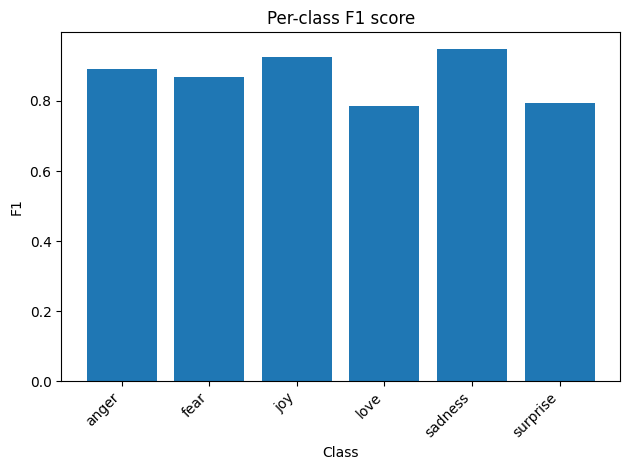

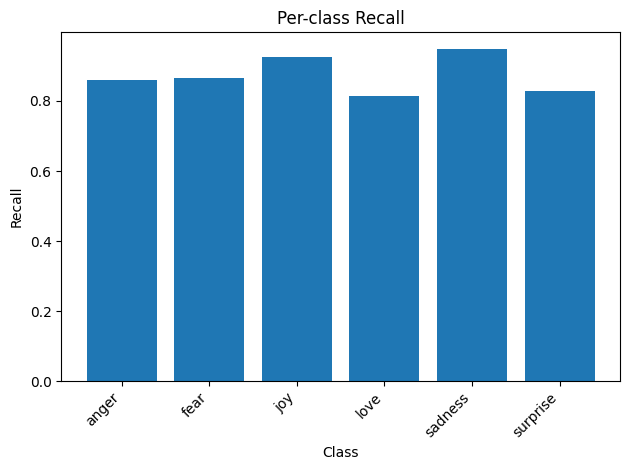

In [25]:
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, sup = precision_recall_fscore_support(out["y_true"], out["y_pred"], average=None)

plt.figure()
plt.bar(range(len(f1)), f1)
plt.xticks(range(len(f1)), encoderLabel.classes_, rotation=45, ha="right")
plt.title("Per-class F1 score")
plt.xlabel("Class")
plt.ylabel("F1")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(range(len(rec)), rec)
plt.xticks(range(len(rec)), encoderLabel.classes_, rotation=45, ha="right")
plt.title("Per-class Recall")
plt.xlabel("Class")
plt.ylabel("Recall")
plt.tight_layout()
plt.show()

In [26]:
readme_text = """
# Emotion Classification with BiLSTM

## Overview
This project implements a Bidirectional LSTM (BiLSTM) model for emotion classification on a labeled text dataset.
The notebook covers preprocessing, model training, evaluation, and visualization of results.

## Files Included
- emotion_classifier.ipynb
- report.pdf
- README.md
- requirements.txt
- length_distribution.png
- confusion_matrix.png
- baseline_loss_curves.png
- baseline_validation_accuracy.png

## Environment
- Python 3.12
- PyTorch
- scikit-learn
- NLTK
- numpy, pandas, matplotlib

## How to Run
1. Install dependencies:
   pip install -r requirements.txt
2. Open the notebook:
   jupyter notebook emotion_classifier.ipynb

## Notes
- Fixed data splits for reproducibility
- Vocabulary built on training set only
- All figures in the report are generated by the notebook
"""

with open("README.md", "w") as f:
    f.write(readme_text)

print("README.md written successfully.")

README.md written successfully.


In [27]:
import os
import ipywidgets as widgets
from IPython.display import display

required_files = [
    "emotion_classifier.ipynb",
    "report.pdf",
    "README.md",
    "requirements.txt",
]

missing_files = [f for f in required_files if not os.path.exists(f)]

if not missing_files:
    print("All required files already exist. No upload needed.")
else:
    print("Missing required files:")
    for f in missing_files:
        print(" -", f)

    print("\nPlease upload the missing files below:")

    uploader = widgets.FileUpload(
        accept='',
        multiple=True
    )

    display(uploader)

    def save_uploaded_files(change):
        for filename, fileinfo in uploader.value.items():
            with open(filename, "wb") as f:
                f.write(fileinfo["content"])
            print(f"Uploaded: {filename}")

    uploader.observe(save_uploaded_files, names="value")

Missing required files:
 - emotion_classifier.ipynb
 - report.pdf

Please upload the missing files below:


FileUpload(value={}, description='Upload', multiple=True)

In [28]:
import os
import zipfile

required_files = [
    "emotion_classifier.ipynb",
    "report.pdf",
    "README.md",
    "requirements.txt",
]

optional_files = [
    "length_distribution.png",
    "confusion_matrix.png",
    "baseline_loss_curves.png",
    "baseline_validation_accuracy.png",
]

zip_name = "CE314_Assignment2_Submission.zip"

missing_required = [f for f in required_files if not os.path.exists(f)]

if missing_required:
    print("ZIP NOT CREATED")
    print("Still missing required files:")
    for f in missing_required:
        print(" -", f)
    print("\n⬆Upload them using the upload cell above, then re-run this cell.")
else:
    files_added = []

    with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:
        for f in required_files:
            zipf.write(f)
            files_added.append(f)

        for f in optional_files:
            if os.path.exists(f):
                zipf.write(f)
                files_added.append(f)

    print("ZIP created:", zip_name)
    print("\nFiles included:")
    for f in files_added:
        print(" -", f)

ZIP NOT CREATED
Still missing required files:
 - emotion_classifier.ipynb
 - report.pdf

⬆Upload them using the upload cell above, then re-run this cell.
